In [2]:
from datasets import load_dataset

/Users/yasir/Desktop/workspace/insurance_ai_engine/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
dataset = load_dataset(path =  "amaye15/invoices-google-ocr", split=None, cache_dir= "../data")

In [7]:
dataset

DatasetDict({
    train: Dataset({
        features: ['pixel_values', 'label', 'ocr'],
        num_rows: 13463
    })
    test: Dataset({
        features: ['pixel_values', 'label', 'ocr'],
        num_rows: 3366
    })
})

In [3]:
print("Dataset splits:", list(dataset.keys()))
print("\nTrain split info:")
print(f"Number of examples: {len(dataset['train'])}")
print(f"Features: {dataset['train'].features}")
print(f"\nTest split info:")
print(f"Number of examples: {len(dataset['test'])}")
print(f"Features: {dataset['test'].features}")

Dataset splits: ['train', 'test']

Train split info:
Number of examples: 13463
Features: {'pixel_values': Image(mode=None, decode=True), 'label': ClassLabel(names=['Barcode', 'Invoice', 'Object', 'Receipt', 'Non-Object']), 'ocr': List({'bounding box': {'vertex 0': {'x': Value('int64'), 'y': Value('int64')}, 'vertex 1': {'x': Value('int64'), 'y': Value('int64')}, 'vertex 2': {'x': Value('int64'), 'y': Value('int64')}, 'vertex 3': {'x': Value('int64'), 'y': Value('int64')}}, 'text': Value('string')})}

Test split info:
Number of examples: 3366
Features: {'pixel_values': Image(mode=None, decode=True), 'label': ClassLabel(names=['Barcode', 'Invoice', 'Object', 'Receipt', 'Non-Object']), 'ocr': List({'bounding box': {'vertex 0': {'x': Value('int64'), 'y': Value('int64')}, 'vertex 1': {'x': Value('int64'), 'y': Value('int64')}, 'vertex 2': {'x': Value('int64'), 'y': Value('int64')}, 'vertex 3': {'x': Value('int64'), 'y': Value('int64')}}, 'text': Value('string')})}


In [4]:
example = dataset['train'][0]
print("Example keys:", list(example.keys()))
print("\nExample content:")
for key, value in example.items():
    print(f"{key}: {str(value)[:100]}..." if len(str(value)) > 100 else f"{key}: {value}")

Example keys: ['pixel_values', 'label', 'ocr']

Example content:
pixel_values: <PIL.PngImagePlugin.PngImageFile image mode=RGB size=595x841 at 0x139B6CE90>
label: 1
ocr: [{'bounding box': {'vertex 0': {'x': 12, 'y': 27}, 'vertex 1': {'x': 566, 'y': 27}, 'vertex 2': {'x'...


In [5]:
label_names = dataset['train'].features['label'].names
all_labels = list(dataset['train']['label'])

samples = {}
for i, name in enumerate(label_names):
    if i in all_labels:
        samples[name] = all_labels.index(i)

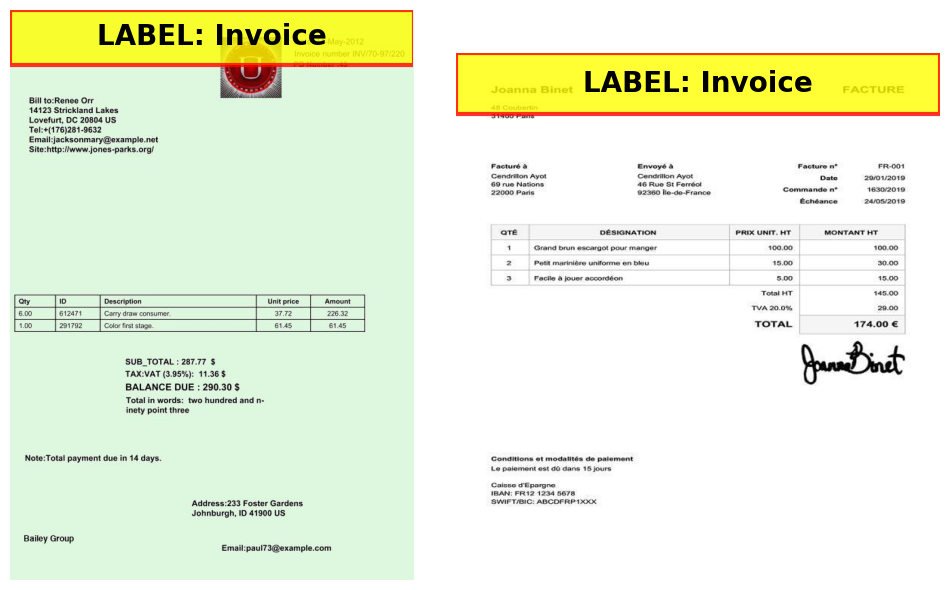

In [35]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import random

label_names = dataset['train'].features['label'].names
all_labels = list(dataset['train']['label'])

samples = []
for i, name in enumerate(label_names):
    indices = [idx for idx, lbl in enumerate(all_labels) if lbl == i]
    if indices:
        num_samples = random.randint(2, 3)
        samples.extend([(name, idx) for idx in random.sample(indices, min(num_samples, len(indices)))])

# Shuffle for random order
random.shuffle(samples)

fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 6))
if len(samples) == 1:
    axes = [axes]

for idx, (label, sample_idx) in enumerate(samples):
    img = dataset['train'][sample_idx]['pixel_values']
    axes[idx].imshow(img)
    w, h = img.size
    rect = Rectangle((0, 0), w, 80, linewidth=3, edgecolor='red', 
                     facecolor='yellow', alpha=0.8, zorder=10)
    axes[idx].add_patch(rect)
    axes[idx].text(w/2, 40, f'LABEL: {label}', ha='center', va='center',
                   fontsize=20, fontweight='bold', color='black', zorder=11)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


In [14]:
type(img)

PIL.PngImagePlugin.PngImageFile

In [14]:
import sys
import os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd())))
from call import encode_image, infer, render_ocr_response

In [9]:
img = dataset['train'][1083]['pixel_values']

In [11]:
encoded_img = encode_image(img)

In [12]:
encoded_img

'...'

In [15]:
response = infer(encoded_img)

In [36]:
samples

[('Invoice', 1083), ('Invoice', 3191)]

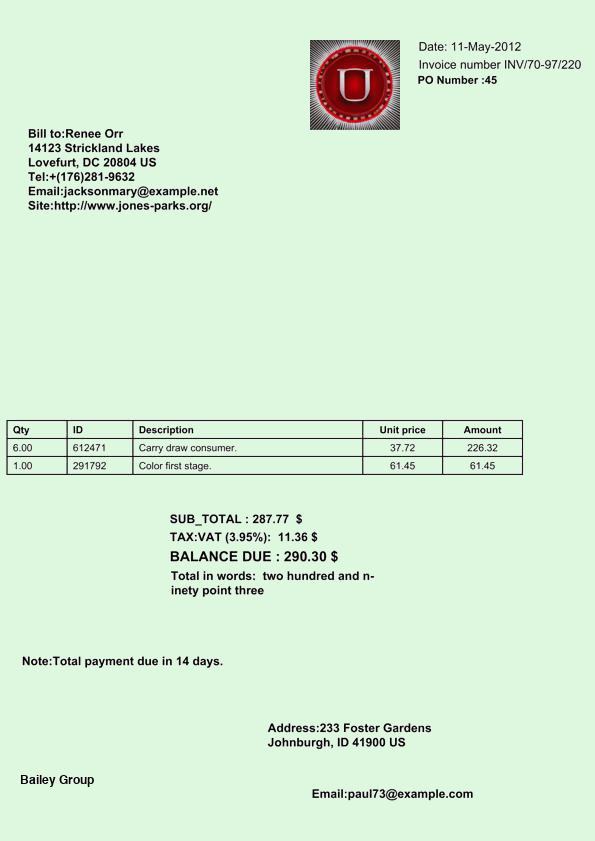

In [42]:
img

In [43]:
render_ocr_response(response)

Date: 11-May-2012 Invoice number INV/70-97/220 PO Number :45                                                       

U                                                                                                                  

Bill to:Renee Orr 14123 Strickland Lakes Lovefurt, DC 20804 US Tel:+(176)281-9632 Email:jacksonmary@example.net    
Site:http://www.jones-parks.org/

┏━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┓
┃ Qty  ┃ ID     ┃ Description          ┃ Unit price ┃ Amount ┃
┡━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━┩
│ Qty  │ ID     │ Description          │ Unit price │ Amount │
│ 6.00 │ 612471 │ Carry draw consumer. │ 37.72      │ 226.32 │
│ 1.00 │ 291792 │ Color first stage.   │ 61.45      │ 61.45  │
└──────┴────────┴──────────────────────┴────────────┴────────┘

SUB_TOTAL : 287.77 $ TAX:VAT (3.95%): 11.36 $ BALANCE DUE : 290.30 $ Total in words: two hundred and n-inety point 
three                                                                                                              

Note:Total payment due in 14 days.                                                                                 

Address:233 Foster Gardens Johnburgh, ID 41900 US                                                                  

Bailey Group Email:paul73@example.com

## Eval


In [1]:
from datasets import load_dataset
from PIL import Image
import evaluate
import sys
import os
from tqdm import tqdm

sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd())))
from call import encode_image, infer, infer_batch

ds = load_dataset(path="amaye15/invoices-google-ocr", split="train", cache_dir="../data")

cer = evaluate.load("cer")

def extract_ground_truth_text(ocr_data):
    """Extract ground truth text from OCR data structure"""
    if isinstance(ocr_data, list):
        # Join all text entries from OCR list
        texts = [item.get("text", "") for item in ocr_data if isinstance(item, dict)]
        return " ".join(texts)
    return ""

def run_ocr(batch, max_workers=5):
    """Run OCR on a batch of images using parallel API calls"""
    images = batch["pixel_values"]
    
    # Prepare images and encode them
    encoded_images = []
    for img in images:
        try:
            # Ensure image is PIL Image in RGB mode
            if isinstance(img, Image.Image):
                img_rgb = img.convert("RGB")
            else:
                # If it's a numpy array or tensor, convert to PIL
                img_rgb = Image.fromarray(img).convert("RGB") if hasattr(img, 'shape') else img
            
            # Encode image to base64
            encoded_img = encode_image(img_rgb)
            encoded_images.append(encoded_img)
        except Exception as e:
            print(f"Error encoding image: {type(e).__name__}: {e}")
            encoded_images.append(None)
    
    # Run parallel inference
    preds = infer_batch(encoded_images, max_workers=max_workers)
    
    batch["nanonets_ocr"] = preds
    return batch

# 5) Select subset first (e.g. 100 examples) - do this BEFORE processing to avoid processing all 13k samples
sample = ds.select(range(100))

# Extract ground truth text from OCR data (only for the selected 100 samples)
print("Extracting ground truth text from OCR data for 100 samples...")
def add_text_column(example):
    """Add text column by extracting from OCR data"""
    example["text"] = extract_ground_truth_text(example.get("ocr", []))
    return example

sample = sample.map(add_text_column)

# Test with a single image first to verify API is working (direct test without map)
print("Testing API with a single image directly...")
test_img = sample[0]["pixel_values"]
if isinstance(test_img, Image.Image):
    test_img_rgb = test_img.convert("RGB")
else:
    test_img_rgb = Image.fromarray(test_img).convert("RGB") if hasattr(test_img, 'shape') else test_img

print("Encoding image...")
encoded_test = encode_image(test_img_rgb)
print(f"Image encoded. Base64 length: {len(encoded_test)}")

print("Calling API (this may take a while)...")
import time
start_time = time.time()
try:
    test_result = infer(encoded_test)
    elapsed = time.time() - start_time
    print(f"✓ API call successful! Took {elapsed:.2f} seconds")
    print(f"OCR result preview: {test_result[:100]}..." if len(test_result) > 100 else f"OCR result: {test_result}")
except Exception as e:
    elapsed = time.time() - start_time
    print(f"✗ API call failed after {elapsed:.2f} seconds: {type(e).__name__}: {e}")
    raise

# 6) Run OCR on all 100 samples with parallel processing
print(f"Processing {len(sample)} examples with parallel API calls (max_workers=5)...")
import time
start_time = time.time()
sample = sample.map(run_ocr, batched=True, batch_size=30, fn_kwargs={"max_workers": 5})
elapsed = time.time() - start_time
print(f"✓ Completed processing in {elapsed:.2f} seconds ({elapsed/len(sample):.2f} seconds per image)")

# 6) Compute CER/WER against ground-truth column "text"
cer_score = cer.compute(
    predictions=sample["nanonets_ocr"],
    references=sample["text"]
)
print("CER on 100 samples:", cer_score)


/Users/yasir/Desktop/workspace/insurance_ai_engine/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Extracting ground truth text from OCR data for 100 samples...
Testing API with a single image directly...
Encoding image...
Image encoded. Base64 length: 219932
Calling API (this may take a while)...
✓ API call successful! Took 5.32 seconds
OCR result preview: White and Sons

Email:cpetersen@example.com
www.WhiteandSons.org

<img>White and Sons Logo</img>

IN...
Processing 100 examples with parallel API calls (max_workers=5)...


Map: 100%|██████████| 100/100 [29:45<00:00, 17.86s/ examples]

✓ Completed processing in 1785.72 seconds (17.86 seconds per image)
CER on 100 samples: 0.7157348163491141


In [ ]:
sample = ds.select(range(100))

In [2]:
cer_score

0.7157348163491141

In [3]:
predictions

NameError: name 'predictions' is not defined

In [6]:
len(sample)

100

In [7]:
sample[0]

{'pixel_values': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=595x841>,
 'label': 1,
 'ocr': [{'bounding box': {'vertex 0': {'x': 12, 'y': 27},
    'vertex 1': {'x': 566, 'y': 27},
    'vertex 2': {'x': 566, 'y': 793},
    'vertex 3': {'x': 12, 'y': 793}},
   'text': 'White and Sons\nEmail:cpetersen@example.com\nwww.WhiteandSons.org\nINVOICE\nZZZ\nBuyer: Thomas Neal\n853 Barnes Street Apt. 985\nLake Robert, NY 19313 US\nTel:+(428)870-5886\nEmail:dcarey@example.com\nSite:http://www.duran.org/\nInvoice number 9Y4M8d-752\nDate: 09-Aug-2007\nDue Date: 08-Aug-2010\nITEMS\nWind be why.\nQUANTITY\nPRICE\n6.00\n$93.70\nDesign actually need.\n5.00\n$30.60\nThat population.\n3.00\n$3.67\nSUB TOTAL: 726.21 EUR\nGST(9%): 65.36\nTOTAL: 740.88 EUR'},
  {'bounding box': {'vertex 0': {'x': 23, 'y': 27},
    'vertex 1': {'x': 56, 'y': 27},
    'vertex 2': {'x': 56, 'y': 37},
    'vertex 3': {'x': 23, 'y': 37}},
   'text': 'White'},
  {'bounding box': {'vertex 0': {'x': 58, 'y': 27},
    'vertex